# Demo

**Chương 8 - Giới thiệu DL cho thị giác máy tính**

Notebook demo này minh họa các nội dung quan trọng trong Chapter 8 của sách *Deep Learning with Python, 2nd Edition*:

- **Convnet/CNN** và lý do phù hợp với dữ liệu ảnh.
- **Convolution**, **filter/kernel**, **response map**, **feature map**.
- **Max pooling**, giảm kích thước không gian và kiểm soát số tham số.
- Huấn luyện convnet từ đầu trên dữ liệu nhỏ và quan sát **overfitting**.
- **Data augmentation** và **dropout** để regularize mô hình ảnh.
- **Pretrained model**, **feature extraction** và **fine-tuning**.

Gợi ý sử dụng trên lớp: chạy lần lượt từ trên xuống. Một số cell huấn luyện có biến cấu hình để chạy nhanh khi demo trực tiếp.

## 0. Chuẩn bị môi trường

Cell dưới đây import các thư viện chính và đặt seed để kết quả ổn định hơn. Nếu chạy trên Colab, TensorFlow thường đã được cài sẵn.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Đặt seed để các phép khởi tạo ngẫu nhiên có xu hướng lặp lại được giữa các lần chạy.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# FAST_RUN=True giúp demo chạy nhanh hơn bằng cách dùng ít dữ liệu/ít epoch hơn.
# Khi muốn kết quả ổn định và biểu đồ rõ hơn, đổi biến này thành False.
FAST_RUN = True

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1780570118.312654   13589 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780570118.781243   13589 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780570120.535360   13589 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: []


W0000 00:00:1780570122.681412   13589 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Convnet đầu tiên với MNIST

Trong chương 8, sách bắt đầu bằng một convnet nhỏ cho MNIST. Điểm quan trọng:

- Ảnh không nên bị xem ngay như vector 1D.
- Input của convnet có dạng **(height, width, channels)**.
- Các lớp **Conv2D** học đặc trưng cục bộ; **MaxPooling2D** giảm kích thước không gian.
- Trước Dense classifier, ta dùng **Flatten** để chuyển feature map 3D thành vector.

Train: (10000, 28, 28, 1) (10000,)
Validation: (2000, 28, 28, 1) (2000,)
Test: (10000, 28, 28, 1) (10000,)


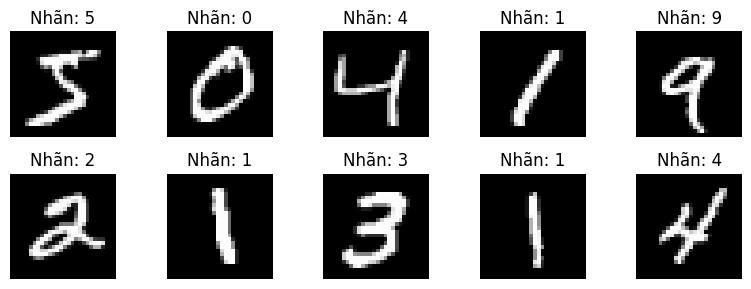

In [ ]:
# Tải bộ dữ liệu MNIST gồm ảnh chữ số viết tay và nhãn tương ứng.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Đưa pixel từ miền [0, 255] về [0, 1] để mô hình học ổn định hơn.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Thêm chiều channel để ảnh grayscale có shape (samples, 28, 28, 1).
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Chọn số lượng mẫu train tùy theo chế độ chạy nhanh hay chạy đầy đủ.
n_train = 10_000 if FAST_RUN else 60_000
n_val = 2_000

# Tách một phần dữ liệu train làm validation để theo dõi khả năng tổng quát hóa.
x_val, y_val = x_train[n_train:n_train + n_val], y_train[n_train:n_train + n_val]
x_train_small, y_train_small = x_train[:n_train], y_train[:n_train]

print("Train:", x_train_small.shape, y_train_small.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

# Hiển thị một vài ảnh đầu tiên để kiểm tra dữ liệu sau tiền xử lý.
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_small[i, :, :, 0], cmap="gray")
    plt.title(f"Nhãn: {y_train_small[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def make_mnist_convnet():
    # Khai báo input ảnh MNIST: cao 28, rộng 28, 1 kênh grayscale.
    inputs = keras.Input(shape=(28, 28, 1))

    # Lớp convolution đầu tiên học 32 mẫu cục bộ kích thước 3x3.
    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", name="conv_1")(inputs)

    # Max pooling giảm kích thước feature map, giữ tín hiệu mạnh nhất trong từng vùng 2x2.
    x = layers.MaxPooling2D(pool_size=2, name="pool_1")(x)

    # Tầng convolution sâu hơn học nhiều đặc trưng hơn từ feature map đã được pooling.
    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", name="conv_2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="pool_2")(x)

    # Tầng convolution cuối học các pattern trừu tượng hơn với 128 filters.
    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", name="conv_3")(x)

    # Chuyển tensor 3D thành vector 1D để đưa vào Dense classifier.
    x = layers.Flatten()(x)

    # Softmax trả về phân phối xác suất trên 10 chữ số từ 0 đến 9.
    outputs = layers.Dense(10, activation="softmax")(x)

    # Tạo model Keras từ input và output đã khai báo bằng Functional API.
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


# Khởi tạo model convnet cho MNIST.
mnist_model = make_mnist_convnet()

# Compile model: chọn optimizer, loss cho bài toán đa lớp nhãn số nguyên, và metric accuracy.
mnist_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# In kiến trúc để quan sát output shape và số tham số ở từng lớp.
mnist_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8447 - loss: 0.5017 - val_accuracy: 0.8685 - val_loss: 0.4324
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9574 - loss: 0.1434 - val_accuracy: 0.9070 - val_loss: 0.2776
Test accuracy MNIST: 0.9310


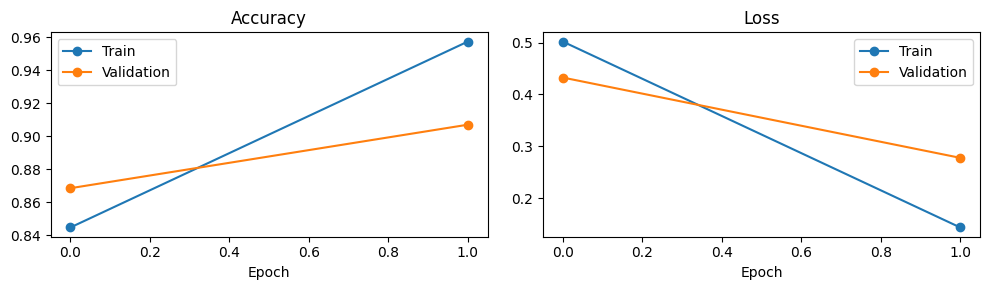

In [ ]:
# Chọn số epoch: ít epoch khi demo nhanh, nhiều hơn khi muốn quan sát học rõ hơn.
epochs_mnist = 2 if FAST_RUN else 5

# Huấn luyện convnet trên tập train và theo dõi performance trên validation set.
history_mnist = mnist_model.fit(
    x_train_small,
    y_train_small,
    epochs=epochs_mnist,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Đánh giá model cuối cùng trên test set chưa dùng trong quá trình train.
test_loss, test_acc = mnist_model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy MNIST: {test_acc:.4f}")

# Vẽ đường accuracy để so sánh train và validation qua từng epoch.
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history_mnist.history["accuracy"], "o-", label="Train")
plt.plot(history_mnist.history["val_accuracy"], "o-", label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

# Vẽ đường loss để phát hiện overfitting nếu validation loss tăng.
plt.subplot(1, 2, 2)
plt.plot(history_mnist.history["loss"], "o-", label="Train")
plt.plot(history_mnist.history["val_loss"], "o-", label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Convolution, filter và response map

Ý tưởng cốt lõi của convolution:

- Một **filter/kernel** nhỏ được trượt qua ảnh.
- Tại mỗi vị trí, kernel tạo một giá trị đáp ứng.
- Tập các giá trị này tạo thành **response map**.
- Một lớp Conv2D có nhiều filter nên tạo nhiều response map, tức nhiều **feature map**.

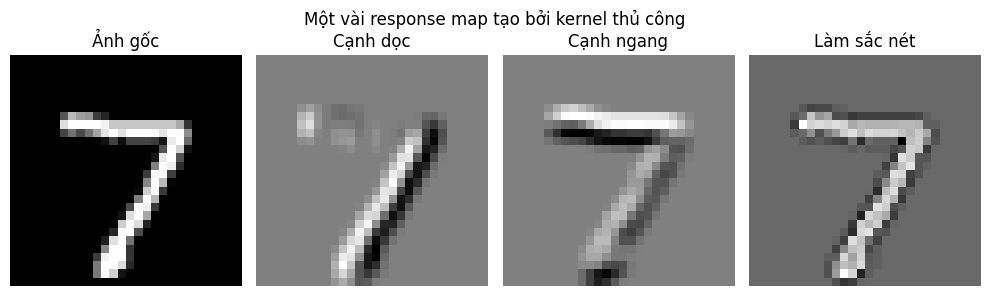

In [ ]:
# Lấy một ảnh MNIST để minh họa cách kernel tạo response map.
img = x_test[0:1]  # Giữ batch dimension để tf.nn.conv2d nhận input 4D.

# Khai báo các kernel thủ công để minh họa những pattern đơn giản.
kernels = {
    "Cạnh dọc": np.array([[-1, 0, 1],
                          [-1, 0, 1],
                          [-1, 0, 1]], dtype="float32"),
    "Cạnh ngang": np.array([[-1, -1, -1],
                            [ 0,  0,  0],
                            [ 1,  1,  1]], dtype="float32"),
    "Làm sắc nét": np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]], dtype="float32"),
}

# Vẽ ảnh gốc ở cột đầu tiên để tiện so sánh với các response map.
plt.figure(figsize=(10, 3))
plt.subplot(1, 4, 1)
plt.imshow(img[0, :, :, 0], cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

for idx, (name, kernel) in enumerate(kernels.items(), start=2):
    # Reshape kernel thành 4D: (kernel_height, kernel_width, input_channels, output_channels).
    k = kernel.reshape((3, 3, 1, 1))

    # Áp dụng convolution thủ công để tạo response map cho từng kernel.
    response = tf.nn.conv2d(img, k, strides=1, padding="SAME").numpy()[0, :, :, 0]

    plt.subplot(1, 4, idx)
    plt.imshow(response, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.suptitle("Một vài response map tạo bởi kernel thủ công")
plt.tight_layout()
plt.show()

## 3. Max pooling và downsampling

**MaxPooling2D** giữ giá trị lớn nhất trong từng vùng nhỏ, thường là 2 x 2.

Tác dụng:

- Giảm kích thước feature map.
- Giảm số hệ số cần xử lý.
- Giữ lại tín hiệu mạnh nhất về sự hiện diện của pattern.
- Giúp tầng sau nhìn được vùng lớn hơn của ảnh ban đầu.

Ảnh gốc: (1, 28, 28, 1)
Sau max pooling: (1, 14, 14, 1)


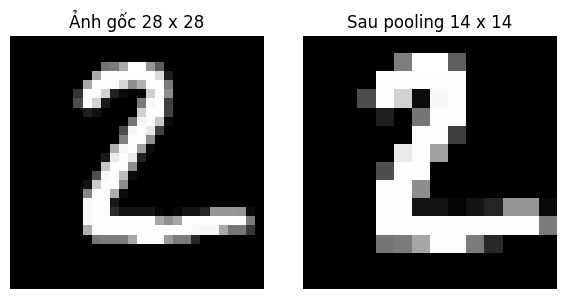

In [ ]:
# Lấy một ảnh test để minh họa max pooling.
sample = x_test[1:2]

# Áp dụng max pooling 2x2, stride 2 để giảm ảnh từ 28x28 xuống 14x14.
pooled = tf.nn.max_pool2d(sample, ksize=2, strides=2, padding="VALID").numpy()

print("Ảnh gốc:", sample.shape)
print("Sau max pooling:", pooled.shape)

# Hiển thị ảnh gốc và ảnh sau pooling để thấy tác dụng giảm kích thước.
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(sample[0, :, :, 0], cmap="gray")
plt.title("Ảnh gốc 28 x 28")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pooled[0, :, :, 0], cmap="gray")
plt.title("Sau pooling 14 x 14")
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Nhìn vào feature map học được

Sau khi model đã được train, ta có thể lấy output của một lớp convolution để xem các **feature map**.

Lưu ý: feature map không phải lúc nào cũng diễn giải được bằng mắt thường, nhưng ta vẫn thấy mỗi channel phản ứng với các pattern khác nhau.

Activation shape: (1, 26, 26, 32)


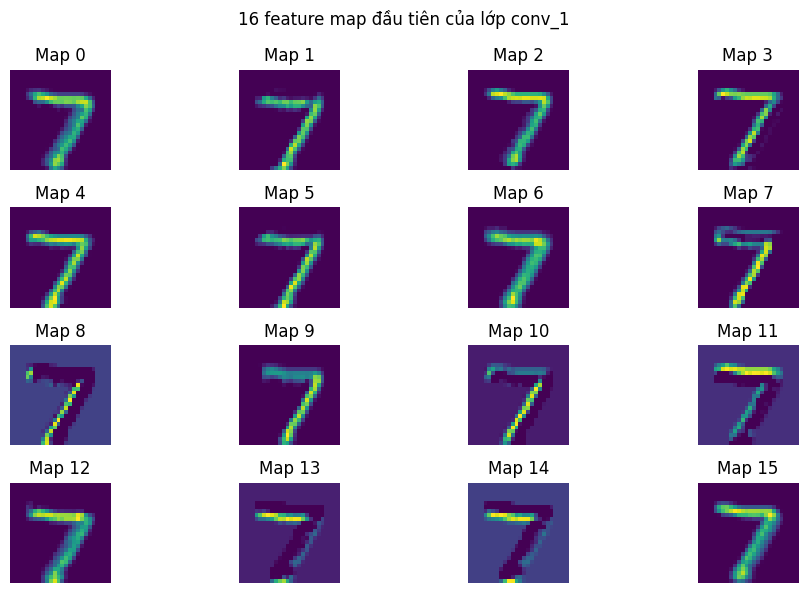

In [ ]:
# Tạo model phụ: input giống model chính, output là activation của lớp conv_1.
activation_model = keras.Model(
    inputs=mnist_model.input,
    outputs=mnist_model.get_layer("conv_1").output,
)

# Chạy một ảnh qua model phụ để lấy toàn bộ feature map của lớp conv_1.
activations = activation_model.predict(x_test[0:1], verbose=0)
print("Activation shape:", activations.shape)

# Hiển thị 16 channel đầu tiên để thấy mỗi filter phản ứng khác nhau.
plt.figure(figsize=(10, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(activations[0, :, :, i], cmap="viridis")
    plt.title(f"Map {i}")
    plt.axis("off")
plt.suptitle("16 feature map đầu tiên của lớp conv_1")
plt.tight_layout()
plt.show()

## 5. Dữ liệu nhỏ: bài toán Cats vs Dogs mini bằng CIFAR-10

Sách dùng Dogs vs. Cats từ Kaggle. Để notebook demo chạy nhanh và không cần tải dữ liệu Kaggle, ta dùng **CIFAR-10** và lọc ra hai lớp:

- `cat` có nhãn 3.
- `dog` có nhãn 5.

Đây vẫn là bài toán binary image classification trên dữ liệu ảnh màu.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 102s 1us/step


/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (1400, 32, 32, 3) (1400,)
Validation: (400, 32, 32, 3) (400,)
Test: (2000, 32, 32, 3) (2000,)


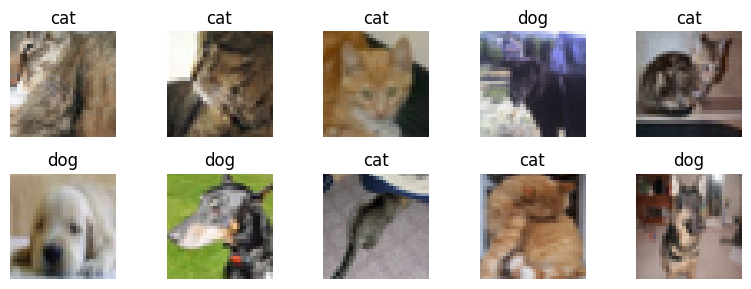

In [ ]:
# Tải CIFAR-10 để tạo bài toán cat/dog mini thay cho dataset Kaggle.
(cifar_train, cifar_y_train), (cifar_test, cifar_y_test) = keras.datasets.cifar10.load_data()

# Loại bỏ chiều dư của nhãn để labels có dạng vector 1D.
cifar_y_train = cifar_y_train.squeeze()
cifar_y_test = cifar_y_test.squeeze()

# Theo quy ước CIFAR-10: cat có nhãn 3, dog có nhãn 5.
CAT_LABEL = 3
DOG_LABEL = 5

def filter_cat_dog(images, labels):
    # Tạo mask để giữ lại chỉ hai lớp cat và dog.
    mask = np.isin(labels, [CAT_LABEL, DOG_LABEL])

    # Lọc ảnh theo mask và scale pixel về [0, 1].
    images = images[mask].astype("float32") / 255.0

    # Lọc nhãn tương ứng với các ảnh đã giữ lại.
    labels = labels[mask]

    # Mã hóa nhãn nhị phân: dog -> 1, cat -> 0.
    labels = (labels == DOG_LABEL).astype("float32")
    return images, labels

# Tạo tập train/test chỉ gồm cat và dog.
cd_train_all, cd_y_train_all = filter_cat_dog(cifar_train, cifar_y_train)
cd_test_all, cd_y_test_all = filter_cat_dog(cifar_test, cifar_y_test)

# Chọn số mẫu mỗi lớp để mô phỏng tình huống dữ liệu ít.
n_per_class_train = 700 if FAST_RUN else 2_000
n_per_class_val = 200 if FAST_RUN else 500

def balanced_subset(images, labels, n_train, n_val):
    # Lấy index của từng lớp để tạo tập cân bằng.
    cat_idx = np.where(labels == 0)[0]
    dog_idx = np.where(labels == 1)[0]

    # Dùng generator có seed để shuffle index ổn định hơn giữa các lần chạy.
    rng = np.random.default_rng(SEED)
    rng.shuffle(cat_idx)
    rng.shuffle(dog_idx)

    # Ghép cùng số lượng cat và dog cho train/validation.
    train_idx = np.r_[cat_idx[:n_train], dog_idx[:n_train]]
    val_idx = np.r_[cat_idx[n_train:n_train + n_val], dog_idx[n_train:n_train + n_val]]

    # Shuffle lại để batch không bị xếp toàn cat trước rồi toàn dog sau.
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return images[train_idx], labels[train_idx], images[val_idx], labels[val_idx]

# Tạo train/validation nhỏ và cân bằng.
x_cd_train, y_cd_train, x_cd_val, y_cd_val = balanced_subset(
    cd_train_all, cd_y_train_all, n_per_class_train, n_per_class_val
)

x_cd_test, y_cd_test = cd_test_all, cd_y_test_all

print("Train:", x_cd_train.shape, y_cd_train.shape)
print("Validation:", x_cd_val.shape, y_cd_val.shape)
print("Test:", x_cd_test.shape, y_cd_test.shape)

# Hiển thị vài ảnh cat/dog để kiểm tra nhãn sau khi lọc.
class_names = {0: "cat", 1: "dog"}
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_cd_train[i])
    plt.title(class_names[int(y_cd_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def make_small_catdog_convnet(use_augmentation=False):
    # Khai báo input ảnh CIFAR-10 RGB kích thước 32x32.
    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs

    # Nếu bật augmentation, áp dụng biến đổi ảnh ngay trong model.
    if use_augmentation:
        x = data_augmentation(x)

    # Ba block convolution/pooling học đặc trưng từ đơn giản đến phức tạp hơn.
    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)

    # Flatten để chuyển feature map sang vector cho classifier nhị phân.
    x = layers.Flatten()(x)

    # Dropout chỉ dùng ở phiên bản augmentation để giảm overfitting.
    if use_augmentation:
        x = layers.Dropout(0.5)(x)

    # Sigmoid trả về xác suất ảnh thuộc lớp dog.
    outputs = layers.Dense(1, activation="sigmoid")(x)

    # Tạo và compile model cho bài toán binary classification.
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Tạo baseline model chưa dùng augmentation/dropout.
baseline_cd_model = make_small_catdog_convnet(use_augmentation=False)
baseline_cd_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,297 (372.25 KB)

 Trainable params: 95,297 (372.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5071 - loss: 0.6978 - val_accuracy: 0.5050 - val_loss: 0.6885
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5471 - loss: 0.6888 - val_accuracy: 0.5350 - val_loss: 0.6817
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5664 - loss: 0.6787 - val_accuracy: 0.5675 - val_loss: 0.6760
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6043 - loss: 0.6657 - val_accuracy: 0.5850 - val_loss: 0.6724
Baseline Cat/Dog test accuracy: 0.5885


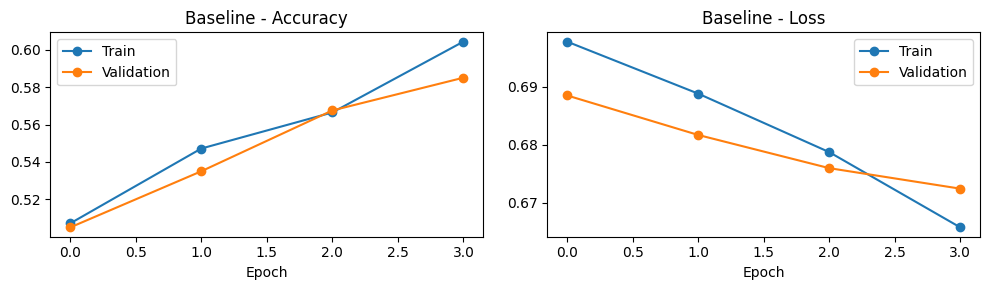

In [ ]:
# Chọn số epoch cho baseline cat/dog.
epochs_cd = 4 if FAST_RUN else 20

# Huấn luyện baseline để quan sát khả năng học và dấu hiệu overfitting.
history_cd = baseline_cd_model.fit(
    x_cd_train,
    y_cd_train,
    epochs=epochs_cd,
    batch_size=64,
    validation_data=(x_cd_val, y_cd_val),
    verbose=1,
)

# Đánh giá baseline trên test set.
test_loss, test_acc = baseline_cd_model.evaluate(x_cd_test, y_cd_test, verbose=0)
print(f"Baseline Cat/Dog test accuracy: {test_acc:.4f}")

def plot_history(history, title):
    # Lấy lịch sử accuracy/loss do Keras trả về sau khi train.
    plt.figure(figsize=(10, 3))

    # Vẽ accuracy để so sánh train và validation.
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], "o-", label="Train")
    plt.plot(history.history["val_accuracy"], "o-", label="Validation")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    # Vẽ loss để phát hiện overfitting rõ hơn.
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], "o-", label="Train")
    plt.plot(history.history["val_loss"], "o-", label="Validation")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cd, "Baseline")

## 6. Data augmentation

Khi dữ liệu ít, model dễ **overfit**. Data augmentation tạo ra các biến thể hợp lệ của ảnh train:

- Lật ngang.
- Xoay nhẹ.
- Zoom nhẹ.
- Dịch ảnh nhẹ.

Mục tiêu không phải tạo thêm thông tin hoàn toàn mới, mà là buộc model học đặc trưng bền vững hơn.

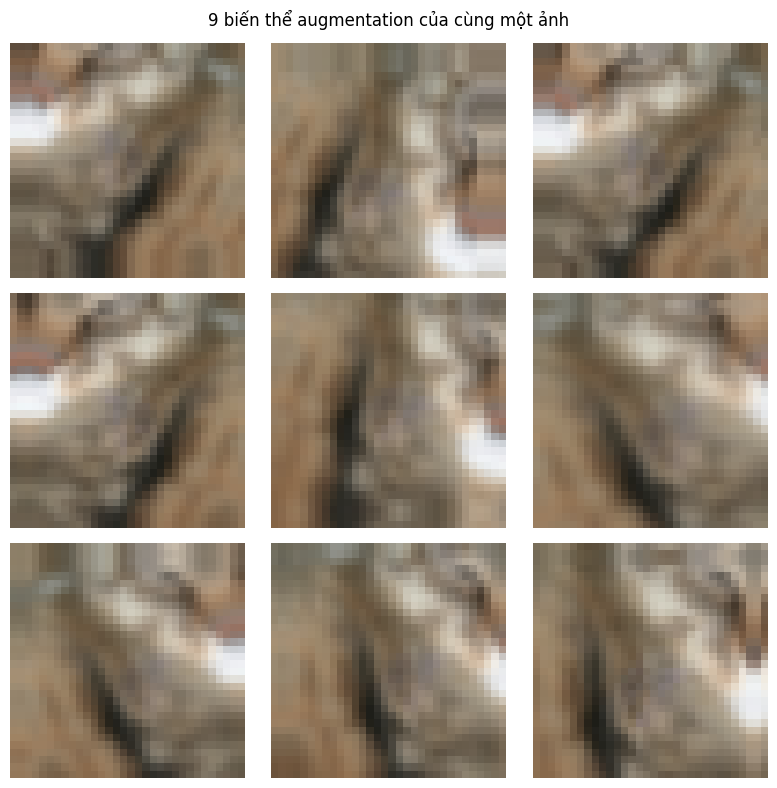

In [ ]:
# Tạo pipeline augmentation để sinh biến thể hợp lệ của ảnh train.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.08, 0.08),
    ],
    name="data_augmentation",
)

# Chọn một ảnh để minh họa các biến đổi augmentation.
sample_img = x_cd_train[0:1]

# Gọi augmentation nhiều lần với training=True để thấy các biến thể ngẫu nhiên.
plt.figure(figsize=(8, 8))
for i in range(9):
    augmented = data_augmentation(sample_img, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 1))
    plt.axis("off")
plt.suptitle("9 biến thể augmentation của cùng một ảnh")
plt.tight_layout()
plt.show()

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4893 - loss: 0.6976 - val_accuracy: 0.5175 - val_loss: 0.6900
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5179 - loss: 0.6933 - val_accuracy: 0.5125 - val_loss: 0.6875
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5429 - loss: 0.6903 - val_accuracy: 0.5150 - val_loss: 0.6840
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5521 - loss: 0.6864 - val_accuracy: 0.5375 - val_loss: 0.6810
Augmented Cat/Dog test accuracy: 0.5490


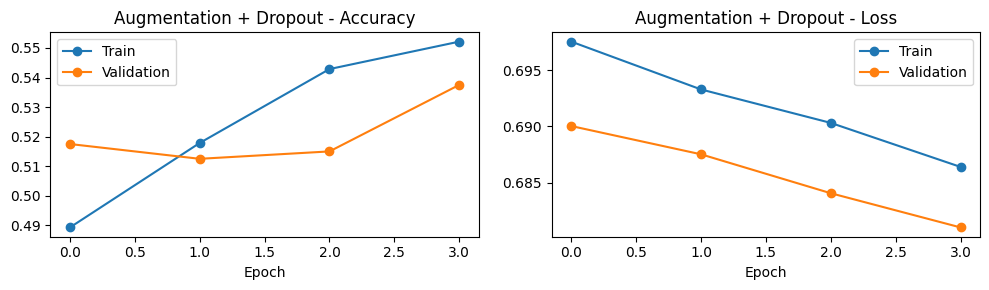

In [ ]:
# Tạo model có augmentation và dropout để regularize.
augmented_cd_model = make_small_catdog_convnet(use_augmentation=True)

# Train lâu hơn khi không chạy nhanh để augmentation có thời gian phát huy tác dụng.
epochs_aug = 4 if FAST_RUN else 30
history_aug = augmented_cd_model.fit(
    x_cd_train,
    y_cd_train,
    epochs=epochs_aug,
    batch_size=64,
    validation_data=(x_cd_val, y_cd_val),
    verbose=1,
)

# Đánh giá model augmentation trên test set.
test_loss, test_acc = augmented_cd_model.evaluate(x_cd_test, y_cd_test, verbose=0)
print(f"Augmented Cat/Dog test accuracy: {test_acc:.4f}")
plot_history(history_aug, "Augmentation + Dropout")

## 7. Pretrained model và feature extraction

Với dữ liệu nhỏ, một chiến lược mạnh hơn là dùng **mô hình đã huấn luyện sẵn**.

Trong sách, mô hình minh họa là **VGG16 pretrained trên ImageNet**. Ta thường:

1. Bỏ classifier gốc bằng `include_top=False`.
2. Giữ lại **convolutional base**.
3. Đóng băng convolutional base bằng `trainable = False`.
4. Thêm classifier mới cho bài toán hiện tại.

Cell dưới đây chỉ trích xuất feature để demo. Lần chạy đầu có thể cần internet để tải weights ImageNet.

In [ ]:
try:
    # Tải convolutional base VGG16 đã học trên ImageNet và bỏ classifier 1000 lớp.
    conv_base = keras.applications.vgg16.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(180, 180, 3),
    )
    print("Đã tải VGG16 pretrained ImageNet.")
except Exception as e:
    # Nếu không tải được weights, vẫn tạo kiến trúc VGG16 để minh họa cấu trúc model.
    print("Không tải được weights ImageNet. Dùng weights=None để vẫn minh họa kiến trúc.")
    print("Lỗi:", repr(e))
    conv_base = keras.applications.vgg16.VGG16(
        weights=None,
        include_top=False,
        input_shape=(180, 180, 3),
    )

# Freeze conv_base để chỉ dùng nó như bộ trích xuất đặc trưng.
conv_base.trainable = False
print("Số trainable weights sau khi freeze:", len(conv_base.trainable_weights))

# In kiến trúc VGG16 để xem feature map co dần qua các block convolution/pooling.
conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Đã tải VGG16 pretrained ImageNet.
Số trainable weights sau khi freeze: 0


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Lấy vài ảnh CIFAR cat/dog để minh họa feature extraction bằng VGG16.
demo_imgs = x_cd_train[:8]

# Resize ảnh từ 32x32 lên 180x180 để khớp input_shape của VGG16.
demo_imgs_180 = tf.image.resize(demo_imgs, (180, 180)).numpy()

# Áp dụng preprocess_input đúng chuẩn VGG16 trước khi đưa ảnh vào conv_base.
demo_preprocessed = keras.applications.vgg16.preprocess_input(demo_imgs_180 * 255.0)

# Chạy forward pass qua convolutional base để lấy feature map.
features = conv_base.predict(demo_preprocessed, verbose=0)

print("Input sau resize:", demo_imgs_180.shape)
print("Feature map từ conv_base:", features.shape)
print("Mỗi ảnh được biểu diễn thành tensor 3D khoảng 5 x 5 x 512.")

Input sau resize: (8, 180, 180, 3)
Feature map từ conv_base: (8, 5, 5, 512)
Mỗi ảnh được biểu diễn thành tensor 3D khoảng 5 x 5 x 512.


In [ ]:
# Biến điều khiển này giúp tránh train pretrained model khi demo trên máy yếu.
RUN_PRETRAINED_TRAINING = False

# Input vẫn là ảnh CIFAR cat/dog 32x32.
inputs = keras.Input(shape=(32, 32, 3))

# Resize ảnh lên 180x180 để đưa vào VGG16.
x = layers.Resizing(180, 180)(inputs)

# Áp dụng augmentation trước preprocessing để tăng đa dạng dữ liệu train.
x = data_augmentation(x)

# Lambda layer dùng preprocess_input của VGG16 ngay trong graph của model.
x = layers.Lambda(
    lambda img: keras.applications.vgg16.preprocess_input(img * 255.0),
    name="vgg16_preprocess",
)(x)

# Dùng conv_base frozen để trích feature map; training=False giữ BatchNorm/Dropout ở chế độ inference nếu có.
x = conv_base(x, training=False)

# Chuyển feature map thành vector rồi đưa qua classifier mới.
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
feature_model = keras.Model(inputs, outputs)

# Compile classifier mới cho bài toán cat/dog.
feature_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

feature_model.summary()

if RUN_PRETRAINED_TRAINING:
    # Chỉ train classifier mới vì conv_base đang frozen.
    history_feature = feature_model.fit(
        x_cd_train,
        y_cd_train,
        epochs=2 if FAST_RUN else 10,
        batch_size=32,
        validation_data=(x_cd_val, y_cd_val),
    )
    plot_history(history_feature, "Feature extraction")
else:
    print("Chưa train feature_model. Đặt RUN_PRETRAINED_TRAINING=True nếu muốn chạy thử.")

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_2' of layer 'functional_3' is incompatible with the layer: expected shape=(None, 32, 32, 3), found shape=(None, 180, 180, 3)[0m

Arguments received by Sequential.call():
  • args=('<KerasTensor shape=(None, 180, 180, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_56>',)
  • kwargs={'mask': 'None'}

## 8. Fine-tuning

**Fine-tuning** khác feature extraction ở chỗ ta mở khóa một phần convolutional base để huấn luyện tiếp.

Quy trình an toàn:

1. Thêm classifier mới lên pretrained base.
2. **Freeze** pretrained base.
3. Train classifier mới trước.
4. **Unfreeze** một vài tầng trên cùng.
5. Train lại với **learning rate nhỏ**.

Không nên mở toàn bộ model ngay từ đầu vì gradient từ classifier mới có thể phá hỏng các biểu diễn pretrained.

In [ ]:
# Mở trainable ở cấp conv_base để có thể fine-tune một phần các layer bên trong.
conv_base.trainable = True

# Chỉ cho phép các layer thuộc block5 cập nhật trọng số; các block thấp hơn vẫn frozen.
for layer in conv_base.layers:
    layer.trainable = layer.name.startswith("block5")

# Lấy danh sách layer trainable/frozen để kiểm tra cấu hình fine-tuning.
trainable_layers = [layer.name for layer in conv_base.layers if layer.trainable]
frozen_layers = [layer.name for layer in conv_base.layers if not layer.trainable]

print("Các layer sẽ được fine-tune:")
for name in trainable_layers:
    print(" -", name)

print("\nSố layer frozen:", len(frozen_layers))
print("Số trainable weights:", len(conv_base.trainable_weights))

# Compile lại với learning rate nhỏ để không phá hỏng biểu diễn pretrained.
feature_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\nModel đã sẵn sàng để fine-tune. Trong demo lớp học, có thể train 1-2 epoch nếu có GPU.")

Các layer sẽ được fine-tune:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool

Số layer frozen: 15
Số trainable weights: 6


NameError: name 'feature_model' is not defined

In [ ]:
# Mặc định tắt fine-tuning để notebook demo không chạy quá lâu.
RUN_FINE_TUNING = False

if RUN_FINE_TUNING:
    # Huấn luyện tiếp classifier và block5 với learning rate nhỏ.
    history_finetune = feature_model.fit(
        x_cd_train,
        y_cd_train,
        epochs=2 if FAST_RUN else 10,
        batch_size=32,
        validation_data=(x_cd_val, y_cd_val),
    )
    plot_history(history_finetune, "Fine-tuning")
else:
    print("Chưa chạy fine-tuning. Đặt RUN_FINE_TUNING=True nếu muốn chạy thử.")

## 9. Tổng kết demo

Các ý chính cần nhớ từ Chapter 8:

- **Convnet** phù hợp với ảnh vì học **local patterns** và **spatial hierarchies**.
- **Filter/kernel** tạo ra **response map**, nhiều response map tạo thành **feature maps**.
- **Max pooling** giảm kích thước feature map và giữ tín hiệu pattern mạnh.
- Khi dữ liệu ít, model dễ **overfit**: train tốt nhưng validation/test kém.
- **Data augmentation** và **dropout** giúp regularize mô hình.
- **Pretrained convnet** giúp tái sử dụng đặc trưng đã học từ dataset lớn.
- **Feature extraction** thường là bước đầu tiên; **fine-tuning** là bước tinh chỉnh thêm để cải thiện kết quả.

Bài tập gợi ý:

1. Đổi `FAST_RUN=False` và quan sát đường cong overfitting rõ hơn.
2. Thử thay đổi số filter trong convnet baseline.
3. Thử bỏ `Dropout` trong model augmentation và so sánh.
4. Nếu có GPU, bật `RUN_PRETRAINED_TRAINING=True` và `RUN_FINE_TUNING=True`.